#1. Set-Up
---

First lets set up the environment, import all libraries used, set Kaggle API token and download the "parking" dataset.

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier


!pip install -q --upgrade kaggle

os.environ["KAGGLE_API_TOKEN"] = "KGAT_5321fd78f78cbd590b9dd1c31bbca744"

!kaggle datasets download -d iasadpanwhar/parking-lot-detection-counter
!unzip -q parking-lot-detection-counter.zip -d parking_dataset
!ls parking_dataset


Dataset URL: https://www.kaggle.com/datasets/iasadpanwhar/parking-lot-detection-counter
License(s): apache-2.0
100% 250M/250M [00:08<00:00, 30.8MB/s]

parking


#2. Paths to Use and Sample Images
---
Now we are setting up the paths to use inside the dataset folder, as well as confirming the amount of samples available for training.

We also show a few sample images from the dataset, to confirm that images are loading correclty and that the classes make sense.

Empty path:  parking_dataset/parking/clf-data/empty
Not empty path:  parking_dataset/parking/clf-data/not_empty
Empty samples:  3045
Not empty samples:  3045



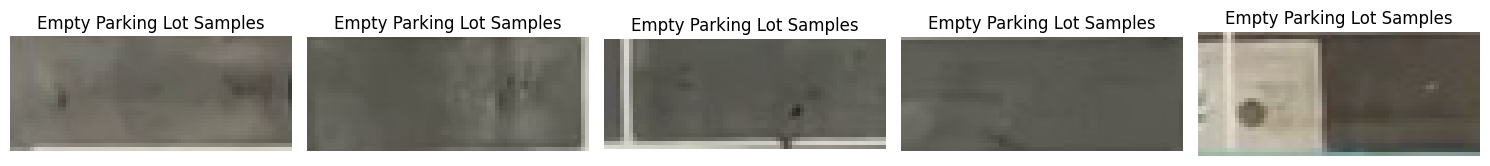

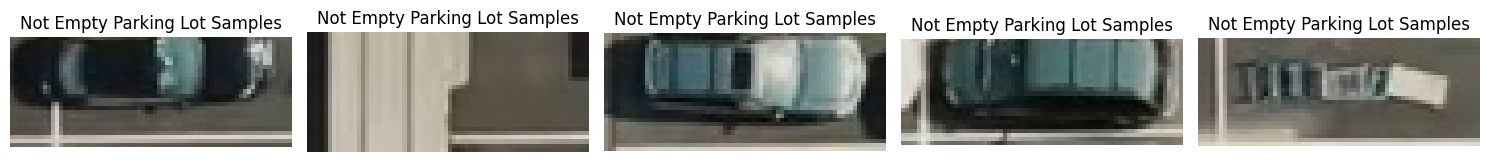

In [ ]:
DATASET_PATH = "parking_dataset/parking/clf-data"
EMPTY_PATH = os.path.join(DATASET_PATH, "empty")
NOT_EMPTY_PATH = os.path.join(DATASET_PATH, "not_empty")

print("Empty path: ", EMPTY_PATH)
print("Not empty path: ", NOT_EMPTY_PATH)
print("Empty samples: ", len(os.listdir(EMPTY_PATH)))
print("Not empty samples: ", len(os.listdir(NOT_EMPTY_PATH)))

print()

def show_sample_images(folder_path, title, num_images = 5):
  files = os.listdir(folder_path)[:num_images]

  plt.figure(figsize=(15, 3))
  for i, filename in enumerate(files):
    file_path = os.path.join(folder_path, filename)
    img = cv2.imread(file_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, num_images, i + 1)
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')

  plt.tight_layout()
  plt.show()

show_sample_images(EMPTY_PATH, "Empty Parking Lot Samples")
show_sample_images(NOT_EMPTY_PATH, "Not Empty Parking Lot Samples")


# 3. Dataset - Load, Preprocess, Build and Split
---
First we load and preprocess the dataset, so that each image becomes a number 0 or 1.

`image → grayscale → resize → flatten → feature vector`


Random Forest and Support Vector Machines do not take images, they need a numeric input.

#
Our next step is to create features `X` and labels `y`, so that we have a parking spot image turned into numbers `X[1]`, and its answer `y[i]`: 0 empty or 1 occupied.

#
Then we split the dataset into **80% training** and **20% testing**; this is how we check if the model actually learned and works.



In [ ]:
IMG_SiZE = (32, 32)

def load_images_from_folder(folder_path, label):
  data = []
  labels = []

  for filename in os.listdir(folder_path):
    file_path = os.path.join(folder_path, filename)
    img = cv2.imread(file_path)

    if img is None:
      continue

    img = cv2.resize(img, IMG_SiZE)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    ftrs = img.flatten()

    data.append(ftrs)
    labels.append(label)

  return data, labels


empty_data, empty_labels = load_images_from_folder(EMPTY_PATH, 0)
not_empty_data, not_empty_labels = load_images_from_folder(NOT_EMPTY_PATH, 1)

X = np.array(empty_data + not_empty_data)
y = np.array(empty_labels + not_empty_labels)

print("---------------------")

print("Samples: ", len(X))
print("Labels: ", len(y))

print("---------------------")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train samples: ", len(X_train))
print("Test samples: ", len(X_test))

print("---------------------")

---------------------
Samples:  6090
Labels:  6090
---------------------
Train samples:  4872
Test samples:  1218
---------------------


#4. Training
---

### Random Forest Model
Creation of the Random Forest Model with 100 decision trees, each tree votes on wheter the image is empty or occupied.

Then training, so the model will look at training examples and learn patters that will separate **empty spots** and **occupied spots**.

Lastly predicts on test images it has never seen. Metrics used:
* Accuracy
* Precision, recall, F1 Score
* Confusion Matrix

### Support Vector Machine
Creation of the SVM Model, so SVM tries to find the best boundary between, **empty parking spots** and **occupied parking spots**. We used a linear kernel.




In [16]:
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, y_train)

random_forest_predictions = random_forest_model.predict(X_test)

print("Random Forest Accuracy: ", accuracy_score(y_test, random_forest_predictions))
print("\nClassification Report: \n")
print(classification_report(y_test, random_forest_predictions))
print("\nConfusion Matrix: \n")
print(confusion_matrix(y_test, random_forest_predictions))

svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

print()
print("--------------------------------------------------------")
print()

svm_predictions = svm_model.predict(X_test)

print("SVM Accuracy: ", accuracy_score(y_test, svm_predictions))
print("\nClassification Report: \n")
print(classification_report(y_test, svm_predictions))
print("\nConfusion Matrix: \n")
print(confusion_matrix(y_test, svm_predictions))

joblib.dump(random_forest_model, 'random_forest_parking_model.pkl')
joblib.dump(svm_model, 'svm_parking_model.pkl')

print()
print("--------------------------------------------------------")
print()

print("Models successfully saved.")


Random Forest Accuracy:  1.0

Classification Report: 

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       609
           1       1.00      1.00      1.00       609

    accuracy                           1.00      1218
   macro avg       1.00      1.00      1.00      1218
weighted avg       1.00      1.00      1.00      1218


Confusion Matrix: 

[[609   0]
 [  0 609]]

--------------------------------------------------------

SVM Accuracy:  0.9786535303776683

Classification Report: 

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       609
           1       1.00      0.96      0.98       609

    accuracy                           0.98      1218
   macro avg       0.98      0.98      0.98      1218
weighted avg       0.98      0.98      0.98      1218


Confusion Matrix: 

[[608   1]
 [ 25 584]]

--------------------------------------------------------

Models successfully saved